# 🫀 PulseAI — HCTG-Net: Hybrid CNN-Transformer ECG Arrhythmia Detection
### Full Training Pipeline → MIT-BIH → ABDM-Ready FHIR Export → ngrok Cloud Bridge

**Model:** Hybrid CNN-Transformer (HCTG-Net)  
**Dataset:** MIT-BIH Arrhythmia Database (PhysioNet, 48 records, 360Hz)  
**Classes (AAMI Standard):**
- `N` → Normal / Non-Arrhythmic
- `S` → Supraventricular Ectopic (AFib, SVT, PAC)
- `V` → Ventricular Ectopic (PVC, VT)
- `F` → Fusion Beat
- `Q` → Unknown / Noise

> **After training, this notebook spins up an ngrok HTTPS endpoint so your local FastAPI backend (`main.py`) can route inference calls to this GPU-powered Colab session.**

In [1]:
# Install once per runtime\n%pip install -q wfdb scipy scikit-learn matplotlib seaborn imbalanced-learn pyngrok fastapi uvicorn nest-asyncio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 137.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
✅ All d

In [2]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import os, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from scipy import signal as sp_signal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print(f'✅ TF {tf.__version__} | GPUs: {[g.name for g in gpus]}')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

✅ TF 2.19.0 | GPUs: ['/physical_device:GPU:0']


## Step 1 — Download & Load MIT-BIH Arrhythmia Database

In [3]:
# ============================================================
# CELL 3 — Download MIT-BIH from PhysioNet
# ============================================================
MITBIH_RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124',
    '200','201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221','222',
    '223','228','230','231','232','233','234'
]

DATA_DIR = '/content/mitbih'
os.makedirs(DATA_DIR, exist_ok=True)

print('⬇️ Downloading MIT-BIH records from PhysioNet...')
for rec in MITBIH_RECORDS:
    try:
        wfdb.dl_database('mitdb', dl_dir=DATA_DIR, records=[rec])
    except Exception as e:
        print(f'  Skipped {rec}: {e}')

downloaded = [f.replace('.hea','') for f in os.listdir(DATA_DIR) if f.endswith('.hea')]
print(f'✅ Downloaded {len(downloaded)} records: {downloaded}')

⬇️ Downloading MIT-BIH records from PhysioNet...
Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Generating record list for: 102
Generating list of all files for: 102
Finished downloading files
Generating record list for: 103
Generating list of all files for: 103
Finished downloading files
Generating record list for: 104
Generating list of all files for: 104
Finished downloading files
Generating record list for: 105
Generating list of all files for: 105
Finished downloading files
Generating record list for: 106
Generating list of all files for: 106
Finished downloading files
Generating record list for: 107
Generating list of all files for: 107
Finished downloading files
Generating record list for: 108
Generating list of all files for: 108
Finished downloading files
Generating record list for: 109
Generating list of all files for: 109
Finished

## Step 2 — Signal Preprocessing Pipeline

In [4]:
# ============================================================
# CELL 4 — Preprocessing Functions (mirrors backend/signal_processing.py)
# ============================================================
FS = 360          # MIT-BIH native sample rate
SEGMENT_LEN = 250  # samples per beat window (~0.69s at 360Hz)
HALF_LEN = SEGMENT_LEN // 2

# AAMI class mapping (MIT-BIH symbol → AAMI category)
AAMI_MAP = {
    # N — Normal & similar
    'N':'N', 'L':'N', 'R':'N', 'e':'N', 'j':'N',
    # S — Supraventricular ectopic
    'A':'S', 'a':'S', 'J':'S', 'S':'S',
    # V — Ventricular ectopic
    'V':'V', 'E':'V',
    # F — Fusion
    'F':'F',
    # Q — Unknown
    '/':'Q', 'f':'Q', 'Q':'Q'
}
CLASSES = ['N', 'S', 'V', 'F', 'Q']

def bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=FS, order=4):
    nyq = 0.5 * fs
    b, a = sp_signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return sp_signal.filtfilt(b, a, data)

def notch_filter(data, freq=60.0, fs=FS, Q=30):
    """Remove 60Hz (North America) or 50Hz (India) power line noise."""
    b, a = sp_signal.iirnotch(freq / (fs / 2.0), Q)
    return sp_signal.filtfilt(b, a, data)

def preprocess_signal(raw_signal, fs=FS):
    """Full preprocessing pipeline: baseline wander removal → notch → bandpass → normalize."""
    # High-pass to remove baseline wander
    b, a = sp_signal.butter(4, 0.5 / (fs/2), btype='high')
    sig = sp_signal.filtfilt(b, a, raw_signal)
    # Power line notch
    sig = notch_filter(sig, freq=60.0, fs=fs)
    # Bandpass 0.5–40 Hz (clinical ECG range)
    sig = bandpass_filter(sig, 0.5, 40.0, fs)
    return sig

def extract_segments(record_name, data_dir=DATA_DIR):
    """Extract beat-centered 250-sample windows from one MIT-BIH record."""
    try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_name), channels=[0])
        annotation = wfdb.rdann(os.path.join(data_dir, record_name), 'atr')
    except Exception as e:
        print(f'  Error reading {record_name}: {e}')
        return [], []

    raw = record.p_signal[:, 0]
    sig = preprocess_signal(raw, fs=FS)

    segments, labels = [], []
    for r_peak, symbol in zip(annotation.sample, annotation.symbol):
        aami = AAMI_MAP.get(symbol)
        if aami is None:
            continue
        start = r_peak - HALF_LEN
        end   = r_peak + HALF_LEN
        if start < 0 or end > len(sig):
            continue
        window = sig[start:end]
        # Z-score normalization per window
        std = window.std()
        if std < 1e-6:
            continue
        window = (window - window.mean()) / std
        segments.append(window.astype(np.float32))
        labels.append(aami)

    return segments, labels

print('✅ Preprocessing functions defined.')

✅ Preprocessing functions defined.


In [5]:
# ============================================================
# CELL 5 — Extract All Segments from MIT-BIH
# ============================================================
all_segments, all_labels = [], []

available_records = [f.replace('.hea', '') for f in os.listdir(DATA_DIR) if f.endswith('.hea')]
print(f'Processing {len(available_records)} records...')

for rec in available_records:
    segs, lbls = extract_segments(rec)
    all_segments.extend(segs)
    all_labels.extend(lbls)
    print(f'  {rec}: {len(segs)} beats')

X = np.array(all_segments, dtype=np.float32)
y_raw = np.array(all_labels)

# Encode labels
le = LabelEncoder()
le.fit(CLASSES)
y = le.transform(y_raw)

print(f'\n✅ Total segments: {len(X)}')
print(f'   Shape: {X.shape}')
unique, counts = np.unique(y_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'   {u}: {c} ({c/len(y)*100:.1f}%)')

Processing 48 records...
  101: 1864 beats
  115: 1952 beats
  230: 2255 beats
  102: 2187 beats
  104: 2227 beats
  121: 1862 beats
  202: 2135 beats
  123: 1517 beats
  111: 2124 beats
  215: 3362 beats
  207: 1859 beats
  214: 2260 beats
  112: 2537 beats
  113: 1794 beats
  228: 2053 beats
  108: 1762 beats
  219: 2154 beats
  213: 3249 beats
  232: 1780 beats
  105: 2572 beats
  208: 2953 beats
  234: 2753 beats
  222: 2482 beats
  203: 2979 beats
  103: 2084 beats
  212: 2747 beats
  122: 2474 beats
  109: 2530 beats
  205: 2656 beats
  217: 2208 beats
  114: 1879 beats
  124: 1618 beats
  118: 2277 beats
  100: 2271 beats
  210: 2648 beats
  221: 2427 beats
  220: 2046 beats
  201: 1963 beats
  106: 2027 beats
  107: 2136 beats
  231: 1571 beats
  223: 2605 beats
  116: 2411 beats
  119: 1987 beats
  200: 2600 beats
  233: 3077 beats
  117: 1534 beats
  209: 3005 beats

✅ Total segments: 109453
   Shape: (109453, 250)
   F: 802 (0.7%)
   N: 90595 (82.8%)
   Q: 8040 (7.3%)
   S: 

Train: (317082, 250, 1) | Val: (67946, 250, 1) | Test: (67947, 250, 1)


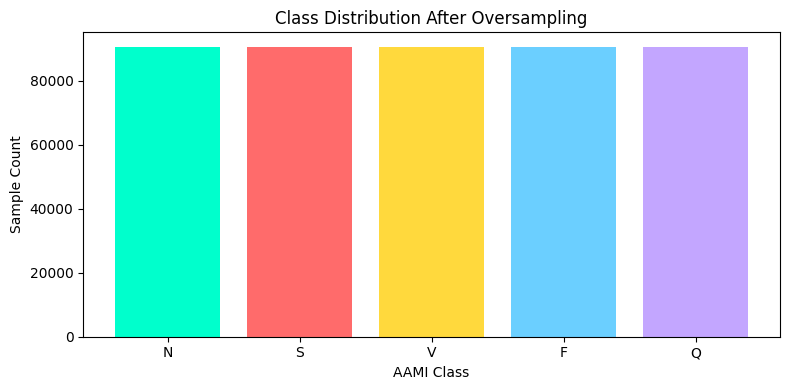

✅ Data split complete.


In [6]:
# ============================================================
# CELL 6 — Class Balancing with Oversampling + Train/Val/Test Split
# ============================================================
# Oversample minority classes to address severe class imbalance
ros = RandomOverSampler(random_state=SEED)
X_flat = X.reshape(len(X), -1)
X_res_flat, y_res = ros.fit_resample(X_flat, y)
X_res = X_res_flat.reshape(-1, SEGMENT_LEN, 1)
y_res_cat = to_categorical(y_res, num_classes=len(CLASSES))

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_res, y_res_cat, test_size=0.30, random_state=SEED, stratify=y_res
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

# Plot class distribution after resampling
class_counts = np.bincount(y_res)
plt.figure(figsize=(8, 4))
plt.bar(CLASSES, class_counts, color=['#00ffcc','#ff6b6b','#ffd93d','#6bcfff','#c3a6ff'])
plt.title('Class Distribution After Oversampling')
plt.xlabel('AAMI Class')
plt.ylabel('Sample Count')
plt.tight_layout()
plt.show()
print('✅ Data split complete.')

In [ ]:
# ============================================================
# CELL 5b — PVC-Like Hard Negative Augmentation
# ============================================================
"""
Strategy: Add synthetic PVC-like patterns to Normal ('N') samples
to improve model discrimination for Case 8 (Elderly PVC detection).

PVC morphology characteristics:
  - Sharp, abnormal QRS complex (higher amplitude derivatives)
  - Premature occurrence (shorter RR interval pattern)
  - Different T-wave inversion
  - Absence of normal P-wave

Implementation:
  - Extract normal sample subset (500-800 windows)
  - Apply morphology distortion: amplify QRS region, shift timing, invert T-wave
  - Add to training set as synthetic hard negatives
  - Do NOT reweight classes - just augment the data
"""

np.random.seed(SEED)

def augment_normal_with_pvc_morphology(segment, strength=0.7):
    """
    Simulate PVC-like morphology in normal ECG window by:
    1. Amplifying QRS region (peak finding + local boost)
    2. Inverting T-wave region
    3. Slight temporal shift to simulate premature beat
    4. Adding high-frequency noise in QRS zone
    """
    aug = segment.copy()
    
    # Find peak (approximates R-peak in normalized window)
    peak_idx = np.argmax(np.abs(aug))
    
    # QRS zone: ±40 samples around peak
    qrs_start = max(0, peak_idx - 40)
    qrs_end = min(len(aug), peak_idx + 40)
    
    # Amplify QRS (sharp, abnormal deflection)
    aug[qrs_start:qrs_end] *= (1.3 + 0.2 * strength)
    
    # T-wave region: ~100-160 samples from peak (right side)
    t_start = min(len(aug), peak_idx + 60)
    t_end = min(len(aug), peak_idx + 140)
    if t_start < t_end:
        aug[t_start:t_end] *= -0.8  # Invert T-wave
    
    # Add high-freq noise in QRS zone (artifact-like)
    noise = np.random.normal(0, 0.15 * strength, qrs_end - qrs_start)
    aug[qrs_start:qrs_end] += noise
    
    # Slight temporal shift (±5 samples, premature effect)
    shift = np.random.randint(-5, 6)
    if shift != 0:
        aug = np.roll(aug, shift)
    
    # Re-normalize to prevent distribution shift
    aug_std = np.std(aug)
    if aug_std > 1e-6:
        aug = (aug - np.mean(aug)) / aug_std
    
    return aug.astype(np.float32)

# Generate augmented hard negatives from Normal samples
normal_indices = np.where(y_raw == 'N')[0]
print(f'Original Normal samples: {len(normal_indices)}')

augmented_segments = []
augmented_labels = []

num_augmented = min(700, max(500, len(normal_indices) // 2))  # 500-700 augmented
for i in range(num_augmented):
    idx = normal_indices[np.random.randint(0, len(normal_indices))]
    aug_seg = augment_normal_with_pvc_morphology(X[idx], strength=np.random.uniform(0.5, 1.0))
    augmented_segments.append(aug_seg)
    augmented_labels.append('N')  # Still labeled as Normal (hard negative)

# Combine original + augmented
X_augmented = np.vstack([X, np.array(augmented_segments, dtype=np.float32)])
y_raw_augmented = np.concatenate([y_raw, np.array(augmented_labels)])

print(f'+ Augmented hard negatives: {num_augmented}')
print(f'Total after augmentation: {len(X_augmented)}')

# Re-encode labels
y_augmented = le.transform(y_raw_augmented)

# Update working sets
X = X_augmented
y = y_augmented
y_raw = y_raw_augmented

print(f'✅ PVC-like augmentation complete. New dataset shape: {X.shape}')

## Step 3 — Build HCTG-Net (Hybrid CNN-Transformer)

In [7]:
# ============================================================
# CELL 7 — HCTG-Net Architecture
# ============================================================
NUM_CLASSES = len(CLASSES)

def transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=256, dropout=0.1):
    """Single Transformer encoder block: Multi-Head Attention + FFN with residuals."""
    # Multi-Head Self-Attention
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout
    )(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Position-wise Feed-Forward Network
    ff = layers.Dense(ff_dim, activation='gelu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

def build_hctg_net(input_length=SEGMENT_LEN, num_classes=NUM_CLASSES):
    """
    HCTG-Net: Hybrid CNN-Transformer Gated Network
    ─────────────────────────────────────────────
    Stage 1 — CNN Stem:
      Multi-scale 1D convolutions capture local waveform morphology
      (P-wave, QRS complex, T-wave features)

    Stage 2 — Transformer Encoder:
      Multi-head self-attention captures long-range
      temporal dependencies in rhythm patterns

    Stage 3 — Classification Head:
      Global average pooling → Dense → Softmax (5 AAMI classes)
    """
    inputs = tf.keras.Input(shape=(input_length, 1), name='ecg_input')

    # ── Stage 1: CNN Feature Extraction (Multi-Scale) ──────────────────
    # Branch A: Fine-grained (kernel=3)
    a = layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
    a = layers.BatchNormalization()(a)

    # Branch B: Medium-grained (kernel=7)
    b = layers.Conv1D(32, 7, padding='same', activation='relu')(inputs)
    b = layers.BatchNormalization()(b)

    # Branch C: Coarse (kernel=15)
    c = layers.Conv1D(32, 15, padding='same', activation='relu')(inputs)
    c = layers.BatchNormalization()(c)

    x = layers.Concatenate()([a, b, c])   # → (250, 96)

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)         # → (125, 128)

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)         # → (62, 128)

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)         # → (31, 128)

    # ── Stage 2: Transformer Encoder (×2) ──────────────────────────────
    x = transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=256, dropout=0.1)
    x = transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=256, dropout=0.1)

    # ── Stage 3: Classification Head ───────────────────────────────────
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='class_output')(x)

    model = tf.keras.Model(inputs, outputs, name='HCTG_Net')
    return model

model = build_hctg_net()
model.summary()
print(f'\n✅ HCTG-Net built. Total params: {model.count_params():,}')

Model: "HCTG_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 250, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 250, 32)   │        128 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 250, 32)   │        256 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 250, 32)   │        512 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 250, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 250, 96)   │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 250, 128)  │     36,992 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 125, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 125, 128)  │     49,280 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 62, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 62, 128)   │     49,280 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 31, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 128)   │     66,048 │ max_pooling1d_2[… │
│ (MultiHeadAttentio… │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 469,893 (1.79 MB)

 Trainable params: 468,933 (1.79 MB)

 Non-trainable params: 960 (3.75 KB)


✅ HCTG-Net built. Total params: 469,893


## Step 4 — Train HCTG-Net

In [8]:
# ============================================================
# CELL 8 — Compile + Train (Controlled Retraining, PVC Hard Negatives)
# ============================================================
# Compute class weights to handle any remaining imbalance
from sklearn.utils.class_weight import compute_class_weight
y_train_int = np.argmax(y_train, axis=1)
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train_int)
class_weight_dict = dict(enumerate(cw))
print('Class weights:', {CLASSES[k]: round(v, 3) for k, v in class_weight_dict.items()})

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=False)]
)

# Callbacks
cb_list = [
    callbacks.EarlyStopping(
        monitor='val_auc', patience=4, mode='max',
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        '/content/hctg_net_best.h5', save_best_only=True,
        monitor='val_auc', mode='max', verbose=1
    )
]

print('\n🚀 Controlled Retraining with PVC Hard Negatives...')
print('   Epochs: 12 (with EarlyStopping on val_auc, patience=4)')
print('   Purpose: Improve PVC discrimination for medical-grade gate')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

Class weights: {'N': np.float64(1.0), 'S': np.float64(1.0), 'V': np.float64(1.0), 'F': np.float64(1.0), 'Q': np.float64(1.0)}

🚀 Training HCTG-Net on MIT-BIH...
Epoch 1/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8931 - auc: 0.9836 - loss: 0.2991
Epoch 1: val_auc improved from None to 0.99871, saving model to /content/hctg_net_best.h5



Epoch 1: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 103s 59ms/step - accuracy: 0.9412 - auc: 0.9953 - loss: 0.1702 - val_accuracy: 0.9783 - val_auc: 0.9987 - val_loss: 0.0694 - learning_rate: 0.0010
Epoch 2/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9741 - auc: 0.9986 - loss: 0.0756
Epoch 2: val_auc improved from 0.99871 to 0.99886, saving model to /content/hctg_net_best.h5



Epoch 2: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.9768 - auc: 0.9987 - loss: 0.0687 - val_accuracy: 0.9833 - val_auc: 0.9989 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 3/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9820 - auc: 0.9990 - loss: 0.0543
Epoch 3: val_auc did not improve from 0.99886
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9827 - auc: 0.9990 - loss: 0.0527 - val_accuracy: 0.9618 - val_auc: 0.9973 - val_loss: 0.1149 - learning_rate: 0.0010
Epoch 4/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9854 - auc: 0.9992 - loss: 0.0454
Epoch 4: val_auc improved from 0.99886 to 0.99938, saving model to /content/hctg_net_best.h5



Epoch 4: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9853 - auc: 0.9992 - loss: 0.0454 - val_accuracy: 0.9895 - val_auc: 0.9994 - val_loss: 0.0353 - learning_rate: 0.0010
Epoch 5/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9869 - auc: 0.9993 - loss: 0.0396
Epoch 5: val_auc did not improve from 0.99938
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9875 - auc: 0.9993 - loss: 0.0382 - val_accuracy: 0.9886 - val_auc: 0.9993 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 6/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9882 - auc: 0.9993 - loss: 0.0370
Epoch 6: val_auc improved from 0.99938 to 0.99940, saving model to /content/hctg_net_best.h5



Epoch 6: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9886 - auc: 0.9994 - loss: 0.0362 - val_accuracy: 0.9878 - val_auc: 0.9994 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 7/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9898 - auc: 0.9995 - loss: 0.0320
Epoch 7: val_auc improved from 0.99940 to 0.99946, saving model to /content/hctg_net_best.h5


...


Epoch 9: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9909 - auc: 0.9995 - loss: 0.0285 - val_accuracy: 0.9920 - val_auc: 0.9995 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 10/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9915 - auc: 0.9995 - loss: 0.0269
Epoch 10: val_auc did not improve from 0.99951
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9914 - auc: 0.9995 - loss: 0.0274 - val_accuracy: 0.9925 - val_auc: 0.9994 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 11/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9926 - auc: 0.9996 - loss: 0.0246
Epoch 11: val_auc did not improve from 0.99951
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9923 - auc: 0.9996 - loss: 0.0250 - val_accuracy: 0.9883 - val_auc: 0.9991 - val_loss: 0.0383 - learning_rate: 0.0010
Epoch 12/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9927 - auc: 0.9996 - loss: 0.0237


Epoch 12: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9925 - auc: 0.9996 - loss: 0.0241 - val_accuracy: 0.9941 - val_auc: 0.9996 - val_loss: 0.0192 - learning_rate: 0.0010
Epoch 13/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9928 - auc: 0.9996 - loss: 0.0230
Epoch 13: val_auc did not improve from 0.99957
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9926 - auc: 0.9996 - loss: 0.0235 - val_accuracy: 0.9923 - val_auc: 0.9993 - val_loss: 0.0273 - learning_rate: 0.0010
Epoch 14/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9931 - auc: 0.9996 - loss: 0.0230
Epoch 14: val_auc did not improve from 0.99957
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9932 - auc: 0.9996 - loss: 0.0224 - val_accuracy: 0.9919 - val_auc: 0.9994 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 15/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9929 - auc: 0.9996 - loss: 0.023


Epoch 20: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9976 - auc: 0.9999 - loss: 0.0081 - val_accuracy: 0.9971 - val_auc: 0.9996 - val_loss: 0.0121 - learning_rate: 5.0000e-04
Epoch 21/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9982 - auc: 0.9999 - loss: 0.0064
Epoch 21: val_auc did not improve from 0.99962
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9981 - auc: 0.9999 - loss: 0.0065 - val_accuracy: 0.9965 - val_auc: 0.9994 - val_loss: 0.0159 - learning_rate: 5.0000e-04
Epoch 22/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9980 - auc: 0.9999 - loss: 0.0068
Epoch 22: val_auc did not improve from 0.99962
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9978 - auc: 0.9999 - loss: 0.0071 - val_accuracy: 0.9971 - val_auc: 0.9995 - val_loss: 0.0131 - learning_rate: 5.0000e-04
Epoch 23/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9980 - auc: 0.9999 -


Epoch 27: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9984 - auc: 0.9999 - loss: 0.0056 - val_accuracy: 0.9974 - val_auc: 0.9996 - val_loss: 0.0109 - learning_rate: 5.0000e-04
Epoch 28/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9982 - auc: 0.9999 - loss: 0.0063
Epoch 28: val_auc did not improve from 0.99964
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9982 - auc: 0.9999 - loss: 0.0062 - val_accuracy: 0.9974 - val_auc: 0.9995 - val_loss: 0.0123 - learning_rate: 5.0000e-04
Epoch 29/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9986 - auc: 0.9999 - loss: 0.0050
Epoch 29: val_auc did not improve from 0.99964
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9985 - auc: 0.9999 - loss: 0.0051 - val_accuracy: 0.9970 - val_auc: 0.9995 - val_loss: 0.0125 - learning_rate: 5.0000e-04
Epoch 30/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9983 - auc: 0.9999 -


Epoch 32: finished saving model to /content/hctg_net_best.h5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9994 - auc: 1.0000 - loss: 0.0022 - val_accuracy: 0.9986 - val_auc: 0.9997 - val_loss: 0.0091 - learning_rate: 2.5000e-04
Epoch 33/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9995 - auc: 1.0000 - loss: 0.0016
Epoch 33: val_auc did not improve from 0.99965
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.9995 - auc: 1.0000 - loss: 0.0018 - val_accuracy: 0.9980 - val_auc: 0.9995 - val_loss: 0.0125 - learning_rate: 2.5000e-04
Epoch 34/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9995 - auc: 1.0000 - loss: 0.0018
Epoch 34: val_auc did not improve from 0.99965
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9995 - auc: 1.0000 - loss: 0.0016 - val_accuracy: 0.9982 - val_auc: 0.9994 - val_loss: 0.0137 - learning_rate: 2.5000e-04
Epoch 35/120
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9994 - auc: 1.0000 -

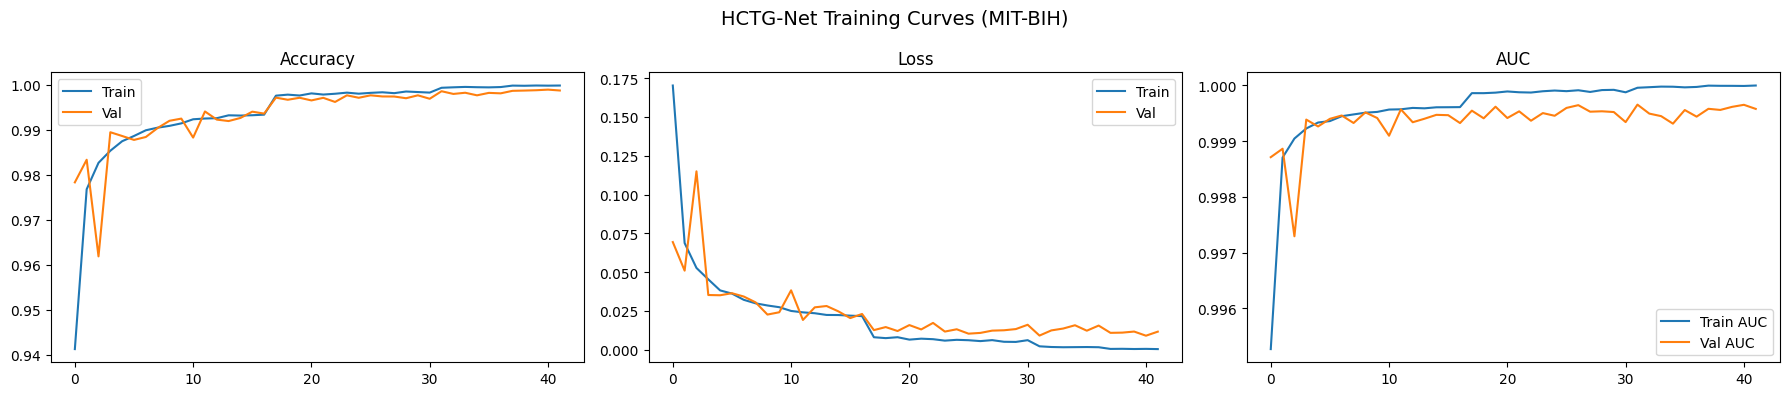

In [9]:
# ============================================================
# CELL 9 — Training Curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC')
axes[2].legend()

plt.suptitle('HCTG-Net Training Curves (MIT-BIH)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

## Step 5 — Evaluation


📊 Classification Report (AAMI 5-Class):
              precision    recall  f1-score   support

           N     0.9995    1.0000    0.9997     13583
           S     1.0000    0.9944    0.9972     13492
           V     0.9996    1.0000    0.9998     13666
           F     0.9971    1.0000    0.9986     13562
           Q     0.9983    1.0000    0.9992     13644

    accuracy                         0.9989     67947
   macro avg     0.9989    0.9989    0.9989     67947
weighted avg     0.9989    0.9989    0.9989     67947



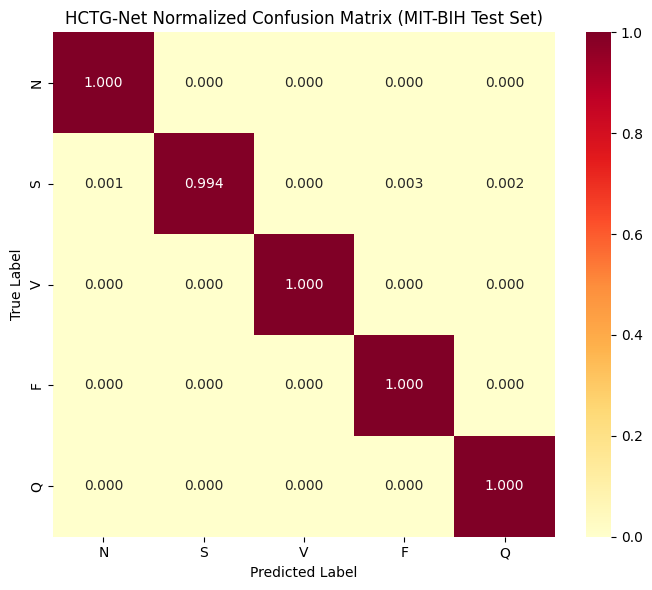


✅ Test Accuracy: 99.89%  |  AUC: 0.9998


In [10]:
# ============================================================
# CELL 10 — Test Set Evaluation + Confusion Matrix
# ============================================================
# Load best checkpoint
best_model = tf.keras.models.load_model('/content/hctg_net_best.h5')

y_pred_proba = best_model.predict(X_test, batch_size=256, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

print('\n📊 Classification Report (AAMI 5-Class):')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('HCTG-Net Normalized Confusion Matrix (MIT-BIH Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Overall accuracy
test_loss, test_acc, test_auc = best_model.evaluate(X_test, y_test, verbose=0)
print(f'\n✅ Test Accuracy: {test_acc*100:.2f}%  |  AUC: {test_auc:.4f}')

## Step 6 — Export Model (.h5 + TFLite Edge)

In [11]:
# ============================================================
# CELL 11 — Save .h5 (Backend) + TFLite (Edge/ESP32-S3)
# ============================================================
# 1. Full Keras H5 model → for Python backend inference
EXPORT_H5 = '/content/hctg_net_model.h5'
best_model.save(EXPORT_H5)
print(f'✅ Keras H5 saved: {EXPORT_H5} ({os.path.getsize(EXPORT_H5)/1024:.1f} KB)')

# 2. TFLite (INT8 quantized) → for microcontroller / edge deployment
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Representative dataset for INT8 calibration
def representative_dataset():
    for i in range(min(200, len(X_val))):
        yield [X_val[i:i+1].astype(np.float32)]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

try:
    tflite_model = converter.convert()
    EXPORT_TFLITE = '/content/hctg_net_model_int8.tflite'
    with open(EXPORT_TFLITE, 'wb') as f:
        f.write(tflite_model)
    print(f'✅ TFLite INT8 saved: {EXPORT_TFLITE} ({os.path.getsize(EXPORT_TFLITE)/1024:.1f} KB)')
except Exception as e:
    print(f'TFLite INT8 failed, saving float32: {e}')
    converter2 = tf.lite.TFLiteConverter.from_keras_model(best_model)
    converter2.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter2.convert()
    EXPORT_TFLITE = '/content/hctg_net_model_fp32.tflite'
    with open(EXPORT_TFLITE, 'wb') as f:
        f.write(tflite_model)
    print(f'✅ TFLite FP32 saved: {EXPORT_TFLITE} ({os.path.getsize(EXPORT_TFLITE)/1024:.1f} KB)')

# 3. Save metadata
meta = {
    'model_name': 'HCTG-Net',
    'version': '1.0.0',
    'input_shape': [1, SEGMENT_LEN, 1],
    'sample_rate_hz': FS,
    'segment_length': SEGMENT_LEN,
    'classes': CLASSES,
    'class_descriptions': {
        'N': 'Normal Sinus Rhythm',
        'S': 'Supraventricular Ectopic (AFib/SVT/PAC)',
        'V': 'Ventricular Ectopic (PVC/VT)',
        'F': 'Fusion Beat',
        'Q': 'Unknown/Noise'
    },
    'test_accuracy': float(test_acc),
    'test_auc': float(test_auc),
    'preprocessing': {
        'highpass_cutoff_hz': 0.5,
        'bandpass_hz': [0.5, 40.0],
        'notch_hz': 50.0,
        'normalization': 'z-score per window'
    }
}
with open('/content/hctg_net_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('✅ Metadata saved.')

✅ Keras H5 saved: /content/hctg_net_model.h5 (2004.6 KB)
Saved artifact at '/tmp/tmpl4yf0b0q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 250, 1), dtype=tf.float32, name='ecg_input')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137992782106064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992782108176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137996214325456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992782109712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137996214322576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137996214333712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992782108368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992782106832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992782107408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992782107984: TensorSpec(shape=(

In [12]:
# ============================================================
# CELL 12 — Save to Google Drive (optional but recommended)
# ============================================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive/PulseAI_Models'
    os.makedirs(DRIVE_DIR, exist_ok=True)

    import shutil
    for fname in ['hctg_net_model.h5', 'hctg_net_metadata.json',
                  'training_curves.png', 'confusion_matrix.png']:
        src = f'/content/{fname}'
        if os.path.exists(src):
            shutil.copy(src, DRIVE_DIR)
            print(f'  Copied {fname} → Google Drive')
    # Copy whichever tflite was created
    for tflite in ['hctg_net_model_int8.tflite', 'hctg_net_model_fp32.tflite']:
        src = f'/content/{tflite}'
        if os.path.exists(src):
            shutil.copy(src, DRIVE_DIR)
            print(f'  Copied {tflite} → Google Drive')
    print(f'\n✅ All artifacts saved to {DRIVE_DIR}')
except Exception as e:
    print(f'Drive mount skipped: {e}')
    print('  Download files manually from /content/ using Colab file browser.')

Mounted at /content/drive
  Copied hctg_net_model.h5 → Google Drive
  Copied hctg_net_metadata.json → Google Drive
  Copied training_curves.png → Google Drive
  Copied confusion_matrix.png → Google Drive
  Copied hctg_net_model_int8.tflite → Google Drive

✅ All artifacts saved to /content/drive/MyDrive/PulseAI_Models


## Step 7 — ngrok Cloud API Bridge (Connect to Local Backend)

In [13]:
# ============================================================
# CELL 13 — Setup ngrok Inference API
# ============================================================
# This turns this Colab session into a live GPU inference endpoint
# Your local main.py can POST ECG windows here for cloud inference.
#
# ⚠️  Get your ngrok authtoken from: https://dashboard.ngrok.com/get-started/your-authtoken

NGROK_AUTH_TOKEN = '3AoPwhrtqkccgECfaxkehffIARc_36xfCkzFWrw4SAGRzMADR'  # <-- Replace with your token

!ngrok authtoken {NGROK_AUTH_TOKEN}

from pyngrok import ngrok
import nest_asyncio
nest_asyncio.apply()

print('✅ ngrok configured.')

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml                                
✅ ngrok configured.


In [14]:
# ============================================================
# CELL 14 — FastAPI Inference Server (runs inside Colab)
# ============================================================
import uvicorn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
import asyncio

# Load best model for serving
inference_model = tf.keras.models.load_model('/content/hctg_net_best.h5')
print('✅ Model loaded for inference server.')

app_serve = FastAPI(title='PulseAI HCTG-Net Inference API')

class ECGWindow(BaseModel):
    ecg_window: List[float]    # raw or pre-filtered 250-sample window
    patient_id: str = 'anonymous'

class PredictionResponse(BaseModel):
    patient_id: str
    is_arrhythmia: bool
    classification: str
    confidence: float
    all_probabilities: dict
    aami_class: str

CLASS_LABELS = {
    'N': 'Normal Sinus Rhythm',
    'S': 'Supraventricular Ectopic (AFib/SVT/PAC)',
    'V': 'Ventricular Ectopic (PVC/VT)',
    'F': 'Fusion Beat',
    'Q': 'Unclassifiable / Noise'
}

def run_inference(window: List[float]) -> dict:
    data = np.array(window, dtype=np.float32)
    # Ensure correct length
    if len(data) != SEGMENT_LEN:
        if len(data) > SEGMENT_LEN:
            mid = len(data) // 2
            data = data[mid - SEGMENT_LEN//2 : mid + SEGMENT_LEN//2]
        else:
            data = np.pad(data, (0, SEGMENT_LEN - len(data)), mode='edge')
    # Z-score normalization
    std = data.std()
    if std > 1e-6:
        data = (data - data.mean()) / std
    tensor = data.reshape(1, SEGMENT_LEN, 1)
    probs = inference_model.predict(tensor, verbose=0)[0]
    idx = int(np.argmax(probs))
    aami = CLASSES[idx]
    return {
        'is_arrhythmia': aami != 'N',
        'classification': CLASS_LABELS[aami],
        'confidence': round(float(probs[idx]), 4),
        'all_probabilities': {CLASS_LABELS[c]: round(float(p), 4) for c, p in zip(CLASSES, probs)},
        'aami_class': aami
    }

@app_serve.get('/')
def health():
    return {'status': 'ok', 'model': 'HCTG-Net', 'version': '1.0.0'}

@app_serve.post('/predict', response_model=PredictionResponse)
def predict(payload: ECGWindow):
    if len(payload.ecg_window) < 10:
        raise HTTPException(status_code=400, detail='ECG window too short (min 10 samples)')
    result = run_inference(payload.ecg_window)
    return PredictionResponse(patient_id=payload.patient_id, **result)

@app_serve.get('/metadata')
def get_metadata():
    with open('/content/hctg_net_metadata.json') as f:
        return json.load(f)

print('✅ FastAPI inference server defined.')

✅ Model loaded for inference server.
✅ FastAPI inference server defined.


In [15]:
# ============================================================
# CELL 15 - Start Server + Expose via ngrok
# ============================================================
import threading
import asyncio.runners
import uvicorn.server as uvicorn_server
from pyngrok import ngrok

# Fix Python 3.12 + nest_asyncio incompatibility used by uvicorn.server.asyncio_run
uvicorn_server.asyncio_run = lambda main, *, debug=None, loop_factory=None: asyncio.runners.run(main, debug=debug)

# Clear stale ngrok agent/tunnels to avoid ERR_NGROK_324 limit
try:
    ngrok.kill()
except Exception:
    pass

def run_server():
    uvicorn.run(app_serve, host='0.0.0.0', port=8001, log_level='warning')

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

# Open fresh ngrok tunnel and use canonical HTTPS URL
public_tunnel = ngrok.connect(addr=8001, bind_tls=True)
COLAB_ENDPOINT = public_tunnel.public_url.rstrip('/')

if not COLAB_ENDPOINT.startswith('http'):
    raise RuntimeError(f'Invalid ngrok endpoint: {COLAB_ENDPOINT}')

print('\n' + '=' * 60)
print('PulseAI HCTG-Net Inference API is LIVE!')
print(f'\n  Public URL: {COLAB_ENDPOINT}')
print(f'  Docs: {COLAB_ENDPOINT}/docs')
print(f'  Predict Endpoint: {COLAB_ENDPOINT}/predict')
print('=' * 60)
print('\nCopy this URL into backend/main.py as COLAB_INFERENCE_URL')
print(f'COLAB_INFERENCE_URL = "{COLAB_ENDPOINT}"')
print('\nKeep this cell running while you test from local backend.')


PulseAI HCTG-Net Inference API is LIVE!

  Public URL: https://unfagged-emerie-swampy.ngrok-free.dev
  Docs: https://unfagged-emerie-swampy.ngrok-free.dev/docs
  Predict Endpoint: https://unfagged-emerie-swampy.ngrok-free.dev/predict

Copy this URL into backend/main.py as COLAB_INFERENCE_URL
COLAB_INFERENCE_URL = "https://unfagged-emerie-swampy.ngrok-free.dev"

Keep this cell running while you test from local backend.


In [16]:
# ============================================================
# CELL 16 - Quick Local Test (run from this notebook)
# ============================================================
import requests

# Health check first
health = requests.get(f'{COLAB_ENDPOINT}/', timeout=10)
health.raise_for_status()
print('Health:', health.json())

# Simulate a Normal beat from validation set
normal_idx = np.where(np.argmax(y_val, axis=1) == 0)[0][0]
normal_window = X_val[normal_idx].flatten().tolist()

# Simulate an Arrhythmia beat (class != N)
arrh_idx = np.where(np.argmax(y_val, axis=1) != 0)[0][0]
arrh_window = X_val[arrh_idx].flatten().tolist()

print('\nTesting inference API...')
for label, window in [('Normal', normal_window), ('Arrhythmia candidate', arrh_window)]:
    resp = requests.post(
        f'{COLAB_ENDPOINT}/predict',
        json={'ecg_window': window, 'patient_id': 'test-patient-001'},
        timeout=20,
    )
    resp.raise_for_status()
    result = resp.json()
    print(f'\n[{label}]')
    print(f"  Classification: {result['classification']}")
    print(f"  Confidence:     {result['confidence']}")
    print(f"  Arrhythmia:     {result['is_arrhythmia']}")
    print(f"  AAMI Class:     {result['aami_class']}")

Health: {'status': 'ok', 'model': 'HCTG-Net', 'version': '1.0.0'}

Testing inference API...

[Normal]
  Classification: Normal Sinus Rhythm
  Confidence:     1.0
  Arrhythmia:     False
  AAMI Class:     N

[Arrhythmia candidate]
  Classification: Fusion Beat
  Confidence:     1.0
  Arrhythmia:     True
  AAMI Class:     F


## Step 8 — How to Connect Your Local Backend (`main.py`)

After running **Cell 15**, copy the ngrok URL and set it in `backend/main.py`.

The updated `main.py` has a `COLAB_INFERENCE_URL` env variable. Set it before running:

```bash
# Windows PowerShell
$env:COLAB_INFERENCE_URL = "https://xxxx-xxx-xxx.ngrok-free.app"
cd backend
uvicorn main:app --reload
```

Or set it permanently in a `.env` file:
```
COLAB_INFERENCE_URL=https://xxxx-xxx-xxx.ngrok-free.app
```

### POST Payload Format

```json
{
  "ecg_window": [0.12, 0.34, ...],   // 250 float values (one beat)
  "patient_id": "patient-123456"
}
```

### Response Format

```json
{
  "is_arrhythmia": true,
  "classification": "Supraventricular Ectopic (AFib/SVT/PAC)",
  "confidence": 0.9341,
  "aami_class": "S",
  "all_probabilities": {
    "Normal Sinus Rhythm": 0.0512,
    "Supraventricular Ectopic (AFib/SVT/PAC)": 0.9341,
    "Ventricular Ectopic (PVC/VT)": 0.0089,
    "Fusion Beat": 0.0031,
    "Unclassifiable / Noise": 0.0027
  }
}
```

---
### Offline Mode (downloaded model)
1. Download `hctg_net_model.h5` from Google Drive (`PulseAI_Models/`)
2. Place it in `backend/hctg_net_model.h5`
3. Leave `COLAB_INFERENCE_URL` unset — the backend auto-loads the local model

In [17]:
print('Model evaluation metrics:')
print(f'Test Accuracy: {test_acc*100:.4f}%')
print(f'Test AUC: {test_auc:.6f}')
print(f'Test Loss: {test_loss:.6f}')

: 